# GNNs for Metallic Glass & Amorphous Alloy Property Prediction

## AI4Physics Learning Workshop — Uppsala University, April 2026

**Tutorial:** Geometric Deep Learning: Hands-on

### What Are Metallic Glasses?

Metallic glasses (MGs) are **amorphous metals** — alloys that lack the long-range periodic order of crystals. Instead of arranging into a regular lattice, the atoms are frozen in a disordered configuration, similar to a liquid.

```
Crystal:          Metallic Glass:
● ● ● ● ●        ●  ● ●  ●
● ● ● ● ●         ●  ●  ● ●
● ● ● ● ●        ● ●  ●  ●
● ● ● ● ●         ●  ● ●  ●
(ordered)         (disordered)
```

**Why are they interesting?**
- Exceptional strength (up to 2× steel) with high elasticity
- Superior corrosion and wear resistance
- Unique magnetic properties (soft magnets, transformers)
- Applications: sports equipment, surgical instruments, electronics casings

**The key question:** What determines whether an alloy can form a glass? This is the **glass-forming ability (GFA)** problem.

### Why GNNs for Metallic Glasses?

- Local atomic environment determines properties — perfect for graph representations
- GNNs can capture short/medium-range order even without long-range periodicity
- Composition can itself be represented as a graph (elements as nodes)

### This Notebook

We take a two-part approach:
1. **Part A:** Predict glass-forming ability from alloy *composition* using a GNN
2. **Part B:** Use pretrained universal potentials (M3GNet) on metallic alloy *structures*

This complements Notebook 01 (crystal GNNs) by tackling the **amorphous** side of materials science.

## 1. Setup & Installation

We use the following libraries:
- **`matminer`** — materials data mining, including the `matbench_glass` dataset
- **`pymatgen`** — crystal structure manipulation and elemental properties
- **`torch` + `torch_geometric`** — build a custom GNN for composition graphs
- **`chgnet`** — pretrained universal potential for Part B (energy + relaxation of metallic alloys)
- **`scikit-learn`** — Random Forest baseline for comparison

In [1]:
# Install dependencies (uncomment if running in Colab)
# !pip install matminer pymatgen torch torch_geometric chgnet ase matplotlib numpy pandas scikit-learn


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Imports successful!")

Imports successful!


---
## Part A: Predicting Glass-Forming Ability from Composition

### The Glass-Forming Ability Problem

Not all alloy compositions can form metallic glasses. When a molten alloy is cooled rapidly (quenched), some compositions freeze into an amorphous solid while others crystallize. Predicting which compositions form glasses is a major open problem.

**Key factors affecting GFA:**
- Atomic size mismatch between elements (>12% helps)
- Negative heat of mixing (strong unlike-atom attraction)
- Multiple components (confusion principle — more elements = harder to crystallize)
- Deep eutectic compositions

### Our Approach: Composition as a Graph

We'll represent each alloy composition as a small graph:
- **Nodes** = elements present in the alloy
- **Node features** = elemental properties (atomic number, electronegativity, radius, etc.) + composition fraction
- **Edges** = fully connected (all elements interact with each other)

This lets us use GNNs even without 3D structure information!

### 2. Load the Metallic Glass Dataset

We use the `matbench_glass` dataset from matminer — a curated binary classification dataset where the task is to predict whether a given composition forms a metallic glass or not.

In [3]:
from matminer.datasets import load_dataset

# Load the metallic glass dataset
df = load_dataset("matbench_glass")
print(f"Dataset size: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df["gfa"].value_counts())
print(f"\nSample entries:")
df.head(10)

Dataset size: 5680
Columns: ['composition', 'gfa']

Class distribution:
gfa
True     4035
False    1645
Name: count, dtype: int64

Sample entries:


,composition,gfa
0,Al,False
1,Al(NiB)2,True
2,Al10Co21B19,True
3,Al10Co23B17,True
4,Al10Co27B13,True
5,Al10Co29B11,False
6,Al10Co31B9,False
7,Al10Co33B7,False
8,Al10Cr3Si7,True
9,Al10Fe23B17,True


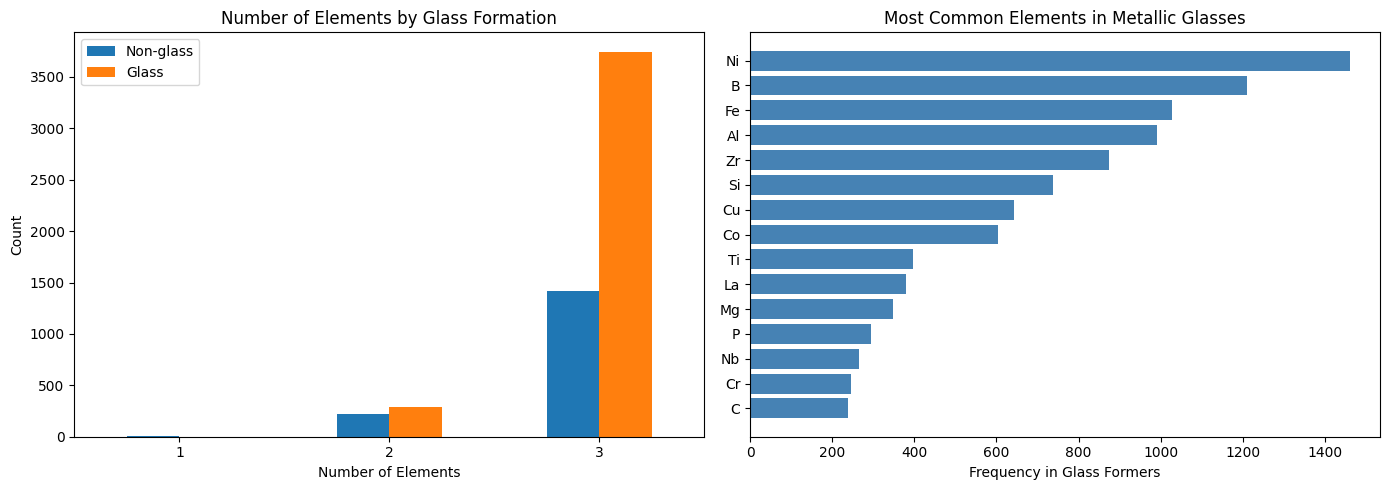

In [4]:
# Explore the dataset
from pymatgen.core import Composition

# Parse compositions
df["composition"] = df["composition"].apply(lambda x: Composition(x) if isinstance(x, str) else x)

# Extract some stats
df["n_elements"] = df["composition"].apply(lambda c: len(c.elements))
df["formula"] = df["composition"].apply(lambda c: c.reduced_formula)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of elements distribution
ax = axes[0]
df.groupby("gfa")["n_elements"].value_counts().unstack(0).plot.bar(ax=ax)
ax.set_xlabel("Number of Elements")
ax.set_ylabel("Count")
ax.set_title("Number of Elements by Glass Formation")
ax.legend(["Non-glass", "Glass"])
ax.tick_params(axis='x', rotation=0)

# Most common elements in glass formers
ax = axes[1]
glass_comps = df[df["gfa"] == True]["composition"]
element_counts = {}
for comp in glass_comps:
    for el in comp.elements:
        element_counts[str(el)] = element_counts.get(str(el), 0) + 1

top_elements = sorted(element_counts.items(), key=lambda x: x[1], reverse=True)[:15]
elements, counts = zip(*top_elements)
ax.barh(range(len(elements)), counts, color='steelblue')
ax.set_yticks(range(len(elements)))
ax.set_yticklabels(elements)
ax.set_xlabel("Frequency in Glass Formers")
ax.set_title("Most Common Elements in Metallic Glasses")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 3. Building Composition Graphs

Now comes the key idea: we represent each alloy composition as a graph that a GNN can process.

For a composition like Cu₅₀Zr₅₀:
- **Node 0**: Cu, with features [Z=29, χ=1.90, r=1.28Å, fraction=0.5]
- **Node 1**: Zr, with features [Z=40, χ=1.33, r=1.60Å, fraction=0.5]
- **Edge 0→1 and 1→0**: These elements interact in the alloy

In [5]:
import torch
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from pymatgen.core import Element

def composition_to_graph(comp, label):
    """Convert a pymatgen Composition to a PyG graph.
    
    Nodes = elements, features = elemental properties + fraction
    Edges = fully connected (all pairs)
    """
    elements = list(comp.as_dict().keys())
    fractions = list(comp.as_dict().values())
    total = sum(fractions)
    fractions = [f / total for f in fractions]  # normalize
    
    # Node features: [atomic_number, electronegativity, atomic_radius, 
    #                  row, group, fraction]
    node_features = []
    for el, frac in zip(elements, fractions):
        elem = Element(el)
        node_features.append([
            elem.Z / 100.0,  # normalize atomic number
            elem.X if elem.X else 1.5,  # electronegativity (Pauling)
            float(elem.atomic_radius) if elem.atomic_radius else 1.5,
            elem.row / 7.0,
            elem.group / 18.0,
            frac,  # composition fraction
        ])
    
    x = torch.tensor(node_features, dtype=torch.float)
    
    # Fully connected edges (all elements interact)
    n = len(elements)
    if n > 1:
        edge_index = torch.tensor(
            [[i, j] for i in range(n) for j in range(n) if i != j],
            dtype=torch.long
        ).t().contiguous()
    else:
        # Single element — self-loop
        edge_index = torch.tensor([[0], [0]], dtype=torch.long)
    
    y = torch.tensor([float(label)], dtype=torch.float)
    return Data(x=x, edge_index=edge_index, y=y)

# Test with an example
test_comp = Composition("Cu50Zr50")
test_graph = composition_to_graph(test_comp, label=1)
print(f"Cu50Zr50 graph:")
print(f"  Nodes: {test_graph.num_nodes}, Edges: {test_graph.num_edges}")
print(f"  Node features shape: {test_graph.x.shape}")
print(f"  Node features (Cu): {test_graph.x[0].tolist()}")
print(f"  Node features (Zr): {test_graph.x[1].tolist()}")

Cu50Zr50 graph:
  Nodes: 2, Edges: 2
  Node features shape: torch.Size([2, 6])
  Node features (Cu): [0.28999999165534973, 1.899999976158142, 1.350000023841858, 0.5714285969734192, 0.6111111044883728, 0.5]
  Node features (Zr): [0.4000000059604645, 1.3300000429153442, 1.5499999523162842, 0.7142857313156128, 0.2222222238779068, 0.5]


In [6]:
# Convert all compositions to graphs
print("Converting compositions to graphs...")
graphs = []
skipped = 0
for idx, row in df.iterrows():
    try:
        g = composition_to_graph(row["composition"], row["gfa"])
        graphs.append(g)
    except Exception as e:
        skipped += 1

print(f"Successfully converted: {len(graphs)} graphs")
print(f"Skipped: {skipped}")

# Train/val/test split
from sklearn.model_selection import train_test_split

train_graphs, test_graphs = train_test_split(graphs, test_size=0.2, random_state=42)
train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.15, random_state=42)

print(f"\nSplit: {len(train_graphs)} train / {len(val_graphs)} val / {len(test_graphs)} test")

# Create data loaders
train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=64)
test_loader = DataLoader(test_graphs, batch_size=64)

Converting compositions to graphs...


Successfully converted: 5680 graphs
Skipped: 0



Split: 3862 train / 682 val / 1136 test


### 4. Building a GNN — Opening the Black Box

Most GNN tutorials jump straight to `from torch_geometric.nn import GCNConv` and treat it as a black box. We'll instead **implement message passing from scratch** so you see exactly what's happening under the hood. Then we'll use our from-scratch layer inside a `GlassGNN` binary classifier.

#### The three primitive operations of message passing

Every message-passing GNN does three things for each layer:

1. **GATHER** — for each edge $(i, j)$, look up the features of the source node: `h_src = h[edge_index[0]]`
2. **TRANSFORM** — compute an edge-level message: some function of source/destination node features and edge features (e.g. linear map, gating, attention)
3. **SCATTER-ADD** — sum all incoming messages into their destination nodes: `out.index_add_(0, dst, messages)`

The specific choice of *message* function is what distinguishes GCN, GAT, GIN, GraphSAGE, CGCNN, MEGNet, MACE, NequIP, etc. The gather/scatter machinery is the same.

We'll implement **GCN** (Kipf & Welling 2017) because its message function is the simplest: a degree-normalized linear map of the source features.

$$h_i^{(l+1)} = \sigma\!\left(\sum_{j \in \mathcal{N}(i) \cup \{i\}} \frac{1}{\sqrt{d_i\, d_j}}\, W^{(l)} h_j^{(l)}\right)$$

where $d_i$ is the degree (number of incoming edges) of node $i$. The $1/\sqrt{d_i d_j}$ factor is what makes GCN spectrally-normalized and stable across graph sizes.

#### 4a. A toy worked example

Let's build a tiny 3-node graph by hand and step through a single message-passing layer, printing every intermediate tensor so you can follow the mechanism.

```
    0 ──→ 1
    │     │
    ↓     ↓
    2 ←───┘
```

Four directed edges: `0→1`, `0→2`, `1→2`, `2→0`.
Each node has a 2-dim feature vector.

In [ ]:
# --- Build the tiny graph ---
h = torch.tensor([
    [1.0, 0.0],   # node 0
    [0.0, 1.0],   # node 1
    [1.0, 1.0],   # node 2
])
edge_index = torch.tensor([
    [0, 0, 1, 2],  # sources
    [1, 2, 2, 0],  # destinations
])
src, dst = edge_index[0], edge_index[1]
print("Node features h:\n", h)
print("edge_index (src / dst):\n", edge_index)

# --- Step 1: GATHER ---
# For each edge, look up the features of the source node.
# This is a simple indexed read; no parameters involved.
h_src = h[src]
print("\nStep 1 (GATHER) — h[src] for each of the 4 edges:")
print(h_src)  # shape [E=4, 2]

# --- Step 2: TRANSFORM (degree-normalized) ---
# For GCN, the message is W @ h_src scaled by 1/sqrt(deg(i)*deg(j)).
# We skip the linear layer W for this illustration and just normalize.
N = h.shape[0]
# Count incoming edges for each node (degree = # of edges ending at that node).
deg = torch.zeros(N)
deg.index_add_(0, dst, torch.ones_like(dst, dtype=torch.float))
print("\nStep 2a — degree of each node (count of incoming edges):", deg.tolist())

# Per-edge normalization factor: 1 / sqrt(deg(src) * deg(dst)).
deg_inv_sqrt = deg.pow(-0.5)
norm = deg_inv_sqrt[src] * deg_inv_sqrt[dst]
messages = h_src * norm.unsqueeze(-1)
print("\nStep 2b — per-edge normalization factors:", norm.tolist())
print("Step 2c — normalized messages for each edge:\n", messages)

# --- Step 3: SCATTER-ADD ---
# For each edge, add its message to the row of 'out' corresponding to that edge's destination.
# Equivalently: out[i] = sum over edges ending at i.
out = torch.zeros_like(h)
out.index_add_(0, dst, messages)
print("\nStep 3 (SCATTER-ADD) — aggregated messages at each node:\n", out)

print("\nThat's a single message-passing layer, without any linear layer or activation.")
print("Stack a few of these and you have a working GNN.")

#### 4b. Same operations, as a reusable module

Now we package the gather / transform / scatter-add sequence as a `torch.nn.Module`. The only additions over the toy example are:
- a learnable linear map `W` before gathering,
- automatic self-loops (so a node always sees its own features),
- a bias term.

This is a *functionally equivalent* reimplementation of `torch_geometric.nn.GCNConv` — we write it out so students can *read* every operation instead of trusting a library call.

In [ ]:
class GCNFromScratch(torch.nn.Module):
    """Graph Convolution (Kipf & Welling 2017), implemented from scratch.

    Decomposes a GNN layer into three primitives:
      (1) GATHER     — index into node features along each edge
      (2) TRANSFORM  — linear map + degree normalization
      (3) SCATTER-ADD — index_add_ the messages into their destination nodes

    This is a drop-in replacement for torch_geometric.nn.GCNConv.
    """

    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = torch.nn.Linear(in_dim, out_dim, bias=False)
        self.bias = torch.nn.Parameter(torch.zeros(out_dim))

    def forward(self, x, edge_index):
        N = x.size(0)

        # Add self-loops so each node aggregates its own features too.
        self_loops = torch.arange(N, device=x.device).unsqueeze(0).repeat(2, 1)
        edge_index = torch.cat([edge_index, self_loops], dim=1)
        src, dst = edge_index[0], edge_index[1]

        # (Linear) apply the learnable W to every node, once.
        h = self.W(x)                                          # [N, out_dim]

        # (1) GATHER — read source-node features along each edge.
        h_src = h[src]                                         # [E, out_dim]

        # (2) TRANSFORM — GCN's normalization is per-edge: 1/sqrt(deg(src)*deg(dst)).
        deg = torch.zeros(N, device=x.device)
        deg.index_add_(0, dst, torch.ones_like(dst, dtype=torch.float))
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0.0
        norm = deg_inv_sqrt[src] * deg_inv_sqrt[dst]           # [E]
        messages = h_src * norm.unsqueeze(-1)                  # [E, out_dim]

        # (3) SCATTER-ADD — sum messages into their destinations.
        out = torch.zeros(N, h.size(1), device=x.device)
        out.index_add_(0, dst, messages)                       # out[dst[e]] += messages[e]

        return out + self.bias


# Quick sanity check against torch_geometric's GCNConv on our toy graph.
from torch_geometric.nn import GCNConv
torch.manual_seed(0)
toy_x = torch.randn(3, 4)
toy_ei = torch.tensor([[0, 0, 1, 2], [1, 2, 2, 0]])

ours = GCNFromScratch(4, 8)
pyg_layer = GCNConv(4, 8, add_self_loops=True, normalize=True, bias=True)
# Copy weights so they compute the same thing.
with torch.no_grad():
    pyg_layer.lin.weight.copy_(ours.W.weight)
    pyg_layer.bias.copy_(ours.bias)

out_ours = ours(toy_x, toy_ei)
out_pyg  = pyg_layer(toy_x, toy_ei)
print("Max abs diff vs torch_geometric.GCNConv:", (out_ours - out_pyg).abs().max().item())
print("→ Our from-scratch GCN matches PyG's GCNConv.")

In [7]:
import torch.nn.functional as F

class GlassGNN(torch.nn.Module):
    """Binary glass-forming-ability classifier built on our from-scratch GCN.

    Architecture:
        Input → GCNFromScratch → ReLU → Dropout
              → GCNFromScratch → ReLU
              → global_mean_pool (graph-level vector)
              → Linear → logit
    """

    def __init__(self, in_channels, hidden_channels=32):
        super().__init__()
        self.conv1 = GCNFromScratch(in_channels, hidden_channels)
        self.conv2 = GCNFromScratch(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        # Two layers of gather → transform → scatter-add.
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.conv2(x, edge_index))

        # Pool: average all node embeddings within each graph to a single vector.
        # (Using PyG's utility here — it's also just a scatter operation.)
        from torch_geometric.nn import global_mean_pool
        x = global_mean_pool(x, batch)

        return self.lin(x).squeeze(-1)

# Initialize model
in_features = 6  # [Z, electronegativity, radius, row, group, fraction]
model = GlassGNN(in_channels=in_features, hidden_channels=32)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

GlassGNN(
  (conv1): GCNConv(6, 32)
  (conv2): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 1,313


In [8]:
# Training loop
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = torch.nn.BCEWithLogitsLoss()

train_losses = []
val_losses = []
val_accs = []

for epoch in range(1, 51):
    # Train
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    train_loss = total_loss / len(train_graphs)
    train_losses.append(train_loss)
    
    # Validate
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            out = model(batch.x, batch.edge_index, batch.batch)
            val_loss += criterion(out, batch.y).item() * batch.num_graphs
            pred = (torch.sigmoid(out) > 0.5).float()
            correct += (pred == batch.y).sum().item()
            total += batch.num_graphs
    
    val_loss /= len(val_graphs)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")

print(f"\nBest validation accuracy: {max(val_accs):.3f} (epoch {np.argmax(val_accs)+1})")

Epoch  10 | Train Loss: 0.5983 | Val Loss: 0.5933 | Val Acc: 0.708


Epoch  20 | Train Loss: 0.5837 | Val Loss: 0.5732 | Val Acc: 0.710


Epoch  30 | Train Loss: 0.5730 | Val Loss: 0.5588 | Val Acc: 0.720


Epoch  40 | Train Loss: 0.5627 | Val Loss: 0.5466 | Val Acc: 0.721


Epoch  50 | Train Loss: 0.5558 | Val Loss: 0.5403 | Val Acc: 0.726

Best validation accuracy: 0.757 (epoch 48)


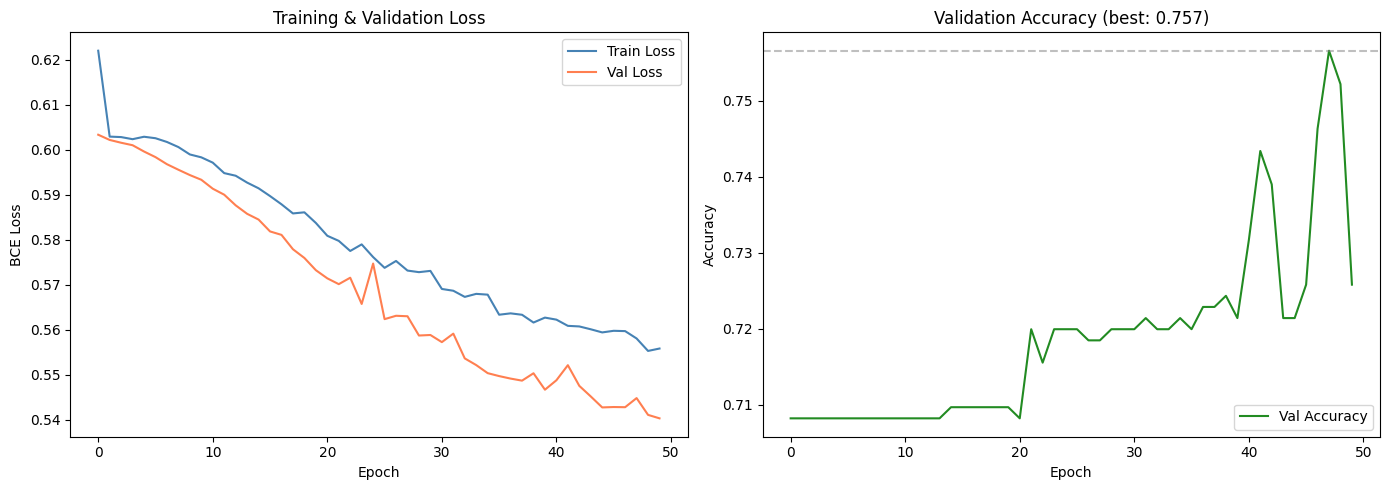

In [9]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(train_losses, label="Train Loss", color='steelblue')
ax.plot(val_losses, label="Val Loss", color='coral')
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("Training & Validation Loss")
ax.legend()

ax = axes[1]
ax.plot(val_accs, label="Val Accuracy", color='forestgreen')
ax.axhline(y=max(val_accs), color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title(f"Validation Accuracy (best: {max(val_accs):.3f})")
ax.legend()

plt.tight_layout()
plt.show()

### 5. Evaluate the GNN

Let's evaluate on the test set and compare with a Random Forest baseline.

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# GNN evaluation on test set
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        out = model(batch.x, batch.edge_index, batch.batch)
        probs = torch.sigmoid(out)
        preds = (probs > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

gnn_acc = accuracy_score(all_labels, all_preds)
gnn_auc = roc_auc_score(all_labels, all_probs)

print("=== GNN Results ===")
print(f"Accuracy: {gnn_acc:.3f}")
print(f"ROC AUC:  {gnn_auc:.3f}")
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Non-glass", "Glass"]))

=== GNN Results ===
Accuracy: 0.729
ROC AUC:  0.698

Classification Report:
              precision    recall  f1-score   support

   Non-glass       0.63      0.09      0.16       320
       Glass       0.73      0.98      0.84       816

    accuracy                           0.73      1136
   macro avg       0.68      0.53      0.50      1136
weighted avg       0.70      0.73      0.65      1136



### 6. Baseline Comparison: Random Forest on Composition Features

A key question in any ML study: does the GNN actually add value over simpler methods? Let's train a Random Forest on hand-crafted composition features using `matminer`.

In [11]:
# Random Forest baseline using matminer composition features
from matminer.featurizers.composition import ElementProperty
from sklearn.ensemble import RandomForestClassifier

# Reload fresh copy of dataset for RF
df_rf = load_dataset("matbench_glass")
df_rf["composition"] = df_rf["composition"].apply(
    lambda x: Composition(x) if isinstance(x, str) else x
)

# Generate Magpie composition features
print("Generating composition features (this may take a minute)...")
ep = ElementProperty.from_preset("magpie")
df_rf = ep.featurize_dataframe(df_rf, "composition", ignore_errors=True)

# Prepare feature matrix
feature_cols = [c for c in df_rf.columns if c not in ["composition", "gfa"]]
df_rf = df_rf.dropna(subset=feature_cols)

X = df_rf[feature_cols].values
y = df_rf["gfa"].values.astype(float)

# Same split ratio
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probs)

print(f"\n=== Random Forest Results ===")
print(f"Accuracy: {rf_acc:.3f}")
print(f"ROC AUC:  {rf_auc:.3f}")
print(f"\n=== Comparison ===")
print(f"GNN Accuracy:  {gnn_acc:.3f} | RF Accuracy:  {rf_acc:.3f}")
print(f"GNN AUC:       {gnn_auc:.3f} | RF AUC:       {rf_auc:.3f}")
print(f"\nNote: The RF baseline uses 100+ hand-crafted Magpie features.")
print("The GNN uses only 6 raw elemental properties — yet captures element interactions!")

Generating composition features (this may take a minute)...


ElementProperty:   0%|          | 0/5680 [00:00<?, ?it/s]


=== Random Forest Results ===
Accuracy: 0.898
ROC AUC:  0.946

=== Comparison ===
GNN Accuracy:  0.729 | RF Accuracy:  0.898
GNN AUC:       0.698 | RF AUC:       0.946

Note: The RF baseline uses 100+ hand-crafted Magpie features.
The GNN uses only 6 raw elemental properties — yet captures element interactions!


---
## Part B: Structure-Based Approach with Pretrained Universal Potentials

Part A worked purely from **composition**. The real power of GNNs in materials science, though, comes from learning on **3D atomic structures**. Universal interatomic potentials like **CHGNet** (Deng et al., *Nature Mach. Intell.* 2023) and **M3GNet** (Chen & Ong, *Nature Comp. Sci.* 2022) were trained on the entire Materials Project and can predict energies for *any* atomic configuration — including metallic alloy structures relevant to glass formers.

### Why this matters for metallic glasses:
- Crystal structures of competing phases tell us about the **energy landscape** 
- The more stable the crystalline phases, the harder it is to form a glass
- These universal potentials also drive molecular dynamics, so you can simulate melt-quench glass formation itself

In [12]:
from chgnet.model import CHGNet
from pymatgen.core import Structure, Lattice

# Load the pretrained CHGNet universal potential
chgnet = CHGNet.load()
print(f"CHGNet loaded — {sum(p.numel() for p in chgnet.parameters()):,} parameters")

# Crystalline phases that *compete* with metallic glass formation
# in well-known glass-forming systems.
metallic_structures = {
    # Cu-Zr — the canonical metallic-glass system
    "Cu (FCC)":  Structure(Lattice.cubic(3.61), ["Cu"], [[0, 0, 0]]),
    "Zr (HCP)":  Structure(Lattice.hexagonal(3.23, 5.15),
                           ["Zr", "Zr"], [[1/3, 2/3, 1/4], [2/3, 1/3, 3/4]]),
    "CuZr (B2)": Structure(Lattice.cubic(3.26), ["Cu", "Zr"],
                           [[0, 0, 0], [0.5, 0.5, 0.5]]),
    # Ni-Nb — another good glass former
    "Ni (FCC)":  Structure(Lattice.cubic(3.52), ["Ni"], [[0, 0, 0]]),
    "Nb (BCC)":  Structure(Lattice.cubic(3.30), ["Nb"], [[0, 0, 0]]),
    # Ti-based glass systems
    "Ti (HCP)":  Structure(Lattice.hexagonal(2.95, 4.68),
                           ["Ti", "Ti"], [[1/3, 2/3, 1/4], [2/3, 1/3, 3/4]]),
}

# Predict energies — CHGNet returns energy per atom
print(f"\n{'Structure':<15}{'E/atom (eV)':>15}{'Max |F| (eV/Å)':>18}")
print("-" * 48)
for name, s in metallic_structures.items():
    out = chgnet.predict_structure(s)
    e_per_atom = float(out["e"])
    max_f = float(np.max(np.abs(out["f"])))
    print(f"{name:<15}{e_per_atom:>15.4f}{max_f:>18.4f}")

print("\nCHGNet gives near-instant DFT-accurate energies for any metallic alloy phase.")


CHGNet v0.3.0 initialized with 412,525 parameters


CHGNet will run on cuda


CHGNet loaded — 412,525 parameters

Structure          E/atom (eV)    Max |F| (eV/Å)
------------------------------------------------


Cu (FCC)               -1.7681            0.0000
Zr (HCP)               -8.5086            0.0000


CuZr (B2)              -6.4522            0.0000
Ni (FCC)               -2.4010            0.0000
Nb (BCC)               -7.3350            0.0000
Ti (HCP)               -7.8170            0.0000

CHGNet gives near-instant DFT-accurate energies for any metallic alloy phase.


CuZr B2 Relaxation with CHGNet
  Initial lattice: a = 3.350 Å


CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda



  Converged in 14 steps
  Final lattice:   a = 3.277 Å
  Initial energy:  -12.8530 eV
  Final energy:    -12.9061 eV   (Δ = -0.0531 eV)


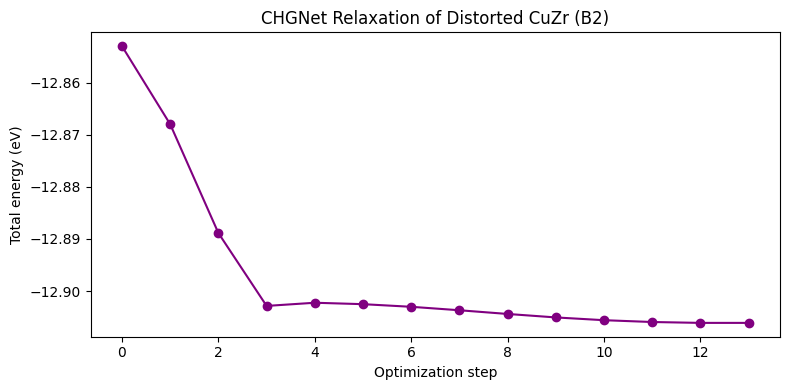


Deeply negative formation energy ⇒ stable crystalline competitor
⇒ strong thermodynamic driving force for crystallization ⇒ harder to form glass.


In [13]:
# Structural relaxation of CuZr (B2) — finding the ground state with CHGNet
from chgnet.model import StructOptimizer

# Start with a slightly distorted CuZr B2 structure
cuzr_distorted = Structure(
    Lattice.cubic(3.35),                                   # slightly expanded lattice
    ["Cu", "Zr"],
    [[0.01, 0.02, 0.0], [0.49, 0.51, 0.50]],               # off-ideal positions
)

print("CuZr B2 Relaxation with CHGNet")
print(f"  Initial lattice: a = {cuzr_distorted.lattice.a:.3f} Å")

relaxer = StructOptimizer()
result  = relaxer.relax(cuzr_distorted, steps=50, fmax=0.05, verbose=False)

relaxed = result["final_structure"]
E = result["trajectory"].energies

print(f"\n  Converged in {len(E)} steps")
print(f"  Final lattice:   a = {relaxed.lattice.a:.3f} Å")
print(f"  Initial energy:  {E[0]:.4f} eV")
print(f"  Final energy:    {E[-1]:.4f} eV   (Δ = {E[-1] - E[0]:+.4f} eV)")

# Visualise the relaxation trajectory
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(E, "o-", color="purple")
ax.set_xlabel("Optimization step")
ax.set_ylabel("Total energy (eV)")
ax.set_title("CHGNet Relaxation of Distorted CuZr (B2)")
plt.tight_layout(); plt.show()

print("\nDeeply negative formation energy ⇒ stable crystalline competitor")
print("⇒ strong thermodynamic driving force for crystallization ⇒ harder to form glass.")


## 7. Discussion: Connecting Composition and Structure

### What We've Learned

**Part A** showed that even a simple GNN on composition graphs can classify glass formers — the graph structure captures element interactions that matter for GFA.

**Part B** demonstrated that pretrained universal potentials can predict energies and relax structures of metallic alloy phases — these energies directly relate to the thermodynamic driving force for crystallization vs. glass formation.

### The Full Picture

In a real research workflow, you might:
1. **Screen compositions** with the GNN classifier (Part A) → find promising glass-forming compositions
2. **Identify competing crystalline phases** from databases or structure prediction
3. **Calculate phase stability** using M3GNet (Part B) → estimate the thermodynamic barrier to crystallization
4. **Simulate glass formation** via melt-quench molecular dynamics with M3GNet → directly observe whether amorphization occurs

### Open Challenges
- **Amorphous structure datasets**: Unlike crystals, there's no "Materials Project for glasses" — generating training data requires expensive MD simulations
- **Long-range disorder**: Standard GNN cutoffs (~5Å) capture local order but may miss medium-range order important in glasses
- **Glass transition**: Predicting the glass transition temperature requires understanding dynamics, not just energy landscapes
- **Multi-component systems**: Real metallic glasses often have 5+ elements — the composition space is vast

## 8. Summary & Resources

### What We Covered
1. **Composition graphs**: Representing alloy compositions as graphs for GNN-based classification
2. **Glass-forming ability prediction**: Binary classification with a simple GCN
3. **Baseline comparison**: GNN vs. Random Forest on hand-crafted features
4. **Pretrained universal potentials**: Using M3GNet for metallic alloy energy prediction and structural relaxation
5. **Physics connection**: How crystal phase stability relates to glass-forming ability

### Key Takeaways
- GNNs can learn **element interactions** directly from data, even from composition alone
- For composition-only tasks, hand-crafted features (Magpie) can be competitive — GNNs shine when structure is available
- **Pretrained universal potentials** (M3GNet, CHGNet, MACE) are transformative for metallic alloy research
- Metallic glass prediction remains challenging — it sits at the intersection of thermodynamics, kinetics, and structure

### Datasets

| Dataset | Size | Type | Access |
|---------|------|------|--------|
| `matbench_glass` | ~5,000 | Binary GFA | `matminer.datasets.load_dataset` |
| `glass_ternary_landolt` | ~7,000 | Ternary glasses | `matminer.datasets.load_dataset` |
| Mendeley MG dataset | ~9,000 | BMG properties | https://data.mendeley.com/datasets/t4bf9fb9hd |
| Materials Project | ~150k+ | Crystal structures | https://materialsproject.org |

### Key Papers
1. Ren et al. "Accelerated discovery of metallic glasses through ML and high-throughput experiments." Science Advances 4, eaaq1566 (2018)
2. Ward et al. "A general-purpose machine learning framework for predicting properties of inorganic materials." npj Comp. Mat. 2, 16028 (2016)
3. Sun et al. "Inverse design of glass structure with deep graph neural networks." Nature Communications 12, 5359 (2021)
4. Chen & Ong. "A Universal Graph Deep Learning Interatomic Potential." Nature Comp. Sci. 2, 718 (2022)
5. Dunn et al. "Benchmarking Materials Property Prediction Methods." npj Comp. Mat. 6, 138 (2020)

### GitHub Repositories
- [`CederGroupHub/chgnet`](https://github.com/CederGroupHub/chgnet) — CHGNet charge-informed universal potential
- [`materialsvirtuallab/matgl`](https://github.com/materialsvirtuallab/matgl) — MEGNet, M3GNet, TensorNet
- [`hackingmaterials/matminer`](https://github.com/hackingmaterials/matminer) — Materials data mining & featurization
- [`pyg-team/pytorch_geometric`](https://github.com/pyg-team/pytorch_geometric) — PyTorch Geometric for custom GNNs
- [`txie-93/cgcnn`](https://github.com/txie-93/cgcnn) — Crystal Graph CNN
- [`ACEsuit/mace`](https://github.com/ACEsuit/mace) — MACE equivariant potentials
- [`JuDFTteam/best-of-atomistic-machine-learning`](https://github.com/JuDFTteam/best-of-atomistic-machine-learning) — Curated list of atomistic ML projects